In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
from src.tracking.track import Track
from src.tracking.track_manager import TrackManager
from src.tracking.kalman_filter import KalmanFilter
from src.evaluation import metrics, plotting
from src.scenarios import (
    truth_generator,
)  # generate truth measurements based on config

In [3]:
from src.models import (
    measurement_models,
    motion_models,
) 

In [4]:
from configs.multi_track_ss_baseline import (
    R,
    Q,
    P0,
    truth_data,
    id_miss_index,
    dt,
    Q,
    measurement_noise,
    ss_baseline_seed,
)  # everything here comes just from baseline

In [5]:
H = measurement_models.H
F = motion_models.F

In [6]:
def angle_between(v1, v2):
    v1_u = v1 / np.linalg.norm(v1)
    v2_u = v2 / np.linalg.norm(v2)
    dot_product = np.dot(v1_u, v2_u)
    angle_rad = np.arccos(np.clip(dot_product, -1.0, 1.0))

    return np.degrees(angle_rad)

In [7]:
ss_baseline_seed()
(truth_states, truth_positions, truth_velocities, truth_times, truth_exists, scans) = (
    truth_generator.generate_truth(
        100, truth_data, P0, id_miss_index, R, dt, measurement_noise
    )
)

In [8]:
# places all of the k-1 tracks into kf objects and track objects.
trax = [
    Track(
        track["id"],
        KalmanFilter(
            F=F,
            H=H,
            R=R,
            Q=Q,
            x_hat_km1_km1=track["x"],
            P_km1_km1=track["P"],
        ),
    )
    for track in truth_data
]
tracker = TrackManager(trax, 5.991)  # all tracks are stored into the trackmanager
# truth_states - For each track id x_i_t = [p_x, p_y, v_x, v_y] for i = {1,2,3,4,5} and t = {k-1, k, k+1, ... k+99}
# truth_positions - For each track id x_i_t = [p_x, p_y] for i = {1,2,3,4,5} and t = {k-1, k, k+1, ... k+99}
# truth_velocities - For each track id x_i_t = [v_x, v_y] for i = {1,2,3,4,5} and t = {k-1, k, k+1, ... k+99}
# truth_times - delta = 1.5, t = {delta*i, delta*i+1,...} for i = {0,1, 2, ... 100}
# truth_exists - truth_exists = {1 if track_i should have a hit at t = k, 0 otherwise}
# scans - {z_1, z_2, z_3, ...} for z_i in F@x + v(0, R) for timestep k_j , j = {k, k+1, ...}
tracker.scan_log[0] = {
    "time": truth_times[0],
    "num_measurements": 0,
    "num_tracks": len(tracker.tracks),
}

for index, measurements in scans.items():
    tracker.scan_log[index] = {
        "time": truth_times[index],
        "num_measurements": len(measurements),
        "num_tracks": len(tracker.tracks),
    }
    tracker.predict_all()
    assignments, unassigned_tracks, unassigned_measurements, _ = tracker.gnn_associate(
        measurements, index
    )

    assignment_map = {a["track_id"]: a["measurement"] for a in assignments}
    unassigned_track_ids = {t["track_id"] for t in unassigned_tracks}
    tracks_to_delete = []

    tracker.pred_log[index] = {}
    for trk in tracker.tracks:
        tracker.pred_log[index][trk.track_id] = [trk.kf.x_hat_k_km1, trk.kf.P_k_km1]

        if trk.track_id in assignment_map:
            z_k = assignment_map[trk.track_id]  # Get measurement from ass map

            trk.update(z_k)  # use measurement / prediction to update
            if trk.track_id in truth_states.keys():
                tracker.log_error(trk, truth_states[trk.track_id][index])
            if trk.tentative:  # if its a tentative track increase hit count by 1
                trk.hit_count += 1
                if trk.hit_count >= 3:  # promote track if hit count >= 2
                    trk.promote_track()
                    print(
                        f"tentative Track ID: {trk.track_id} Promoted! Hit Count: {trk.hit_count}"
                    )
            print(f"Track {trk.track_id} Detected!")

        elif (
            trk.track_id in unassigned_track_ids
        ):  # if this track id is unassigned then mark as a miss and coast
            # predication from k|k-1 -> k|k
            trk.miss()
            trk.coast()
            print(f"Track {trk.track_id} Missed Detection!")

        if (
            trk.tentative and trk.missed_count >= 2
        ):  # delete a tentative track with missed count >= 2
            print(
                f"tentative Track ID: {trk.track_id} Deleted, Missed Count: {trk.missed_count} >= 2"
            )
            tracks_to_delete.append(trk)

        elif (not trk.tentative) and trk.missed_count >= 5:
            # delete a confirmed track with miss count > = 3
            print(
                f"Confirmed Track ID: {trk.track_id} Deleted, Missed Count: {trk.missed_count} >= 3"
            )
            tracks_to_delete.append(trk)

    for trk in tracks_to_delete:  # accutally delete the tracks from the list.
        tracker.delete_track(trk)

    for meas in unassigned_measurements:
        # For each unassigned measurement create a tentative track
        ten_track_id = tracker.tentative_track(
            meas["measurement"],
            tracker.get_new_track_id(),
            F,
            H,
            Q,
            R,
        )
        print(f"tentative Track ID: {ten_track_id} Created!")

Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Missed Detection!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Tr

In [9]:
rmse, _, n = metrics.position_rmse_from_truth_and_predlog(
    truth_states, tracker.pred_log
)
per_track_rmse = metrics.position_rmse_per_track_from_truth_and_predlog(
    truth_states, tracker.pred_log
)
coverage = metrics.track_coverage_from_truth_and_predlog(truth_states, tracker.pred_log)
print("Total Tracks:", max([x.track_id for x in tracker.tracks]))
print("Overall RMSE:", rmse)
print("Per-track RMSE:", per_track_rmse)
print("Coverage:", coverage)
print("Matched samples:", n, "of", int(n / coverage))

Total Tracks: 5
Overall RMSE: 3.7588851538148713
Per-track RMSE: {1: 3.5742998406246236, 2: 4.1702633770813575, 3: 3.621558383109749, 4: 3.824930923310832, 5: 3.568415660004043}
Coverage: 1.0
Matched samples: 500 of 500


In [10]:
metrics.nis_metrics(tracker, truth_data) # NIS BASED

Track_1 NIS: 1.075273908755746
Track_2 NIS: 1.2478080623459904
Track_3 NIS: 1.2648847631337752
Track_4 NIS: 0.7919448127483115
Track_5 NIS: 1.1916761759990373
------

Overall NIS: 1.12437795082185


In [11]:
metrics.nees_metrics(tracker, truth_data)

Track_1 NEES: 2.2969488525521715
Track_2 NEES: 3.301780046329842
Track_3 NEES: 2.366438502466577
Track_4 NEES: 2.1272344398844742
Track_5 NEES: 2.5596507372088335
------

Overall NEES: 2.5434946919575823


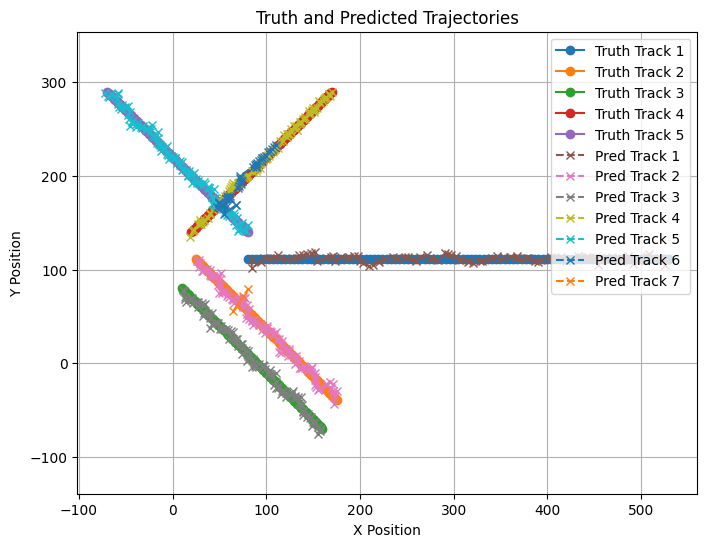

In [12]:
plotting.plot_tracks(truth_positions, tracker)

In [13]:
avg_ospa,median_ospa, per_scan_ospa, per_scan_details = metrics.ospa_from_truth_tracks_and_predlog(
    truth_states=truth_states,
    pred_log=tracker.pred_log,
    c=30.0,
    p=1,
    components=(0, 1,2,3)
)

print("Average OSPA:", avg_ospa)
print("Median OSPA:", median_ospa)
for k in sorted(per_scan_details.keys()):
    d = per_scan_details[k]
    print(
        f"Scan {k}: "
        f"OSPA={per_scan_ospa[k]:.3f}, "
        f"loc={d['localization_component']:.3f}, "
        f"card={d['cardinality_component']:.3f}"
    )



Average OSPA: 5.513632434053638
Median OSPA: 4.669606116845232
Scan 0: OSPA=30.000, loc=0.000, card=0.000
Scan 1: OSPA=0.000, loc=0.000, card=0.000
Scan 2: OSPA=5.777, loc=5.777, card=0.000
Scan 3: OSPA=3.190, loc=3.190, card=0.000
Scan 4: OSPA=4.670, loc=4.670, card=0.000
Scan 5: OSPA=4.166, loc=4.166, card=0.000
Scan 6: OSPA=2.405, loc=2.405, card=0.000
Scan 7: OSPA=2.830, loc=2.830, card=0.000
Scan 8: OSPA=1.832, loc=1.832, card=0.000
Scan 9: OSPA=2.758, loc=2.758, card=0.000
Scan 10: OSPA=1.863, loc=1.863, card=0.000
Scan 11: OSPA=3.289, loc=3.289, card=0.000
Scan 12: OSPA=2.307, loc=2.307, card=0.000
Scan 13: OSPA=7.560, loc=2.560, card=5.000
Scan 14: OSPA=7.774, loc=2.774, card=5.000
Scan 15: OSPA=9.055, loc=4.055, card=5.000
Scan 16: OSPA=8.309, loc=3.309, card=5.000
Scan 17: OSPA=7.694, loc=2.694, card=5.000
Scan 18: OSPA=6.817, loc=1.817, card=5.000
Scan 19: OSPA=7.900, loc=2.900, card=5.000
Scan 20: OSPA=8.946, loc=3.946, card=5.000
Scan 21: OSPA=7.383, loc=2.383, card=5.000
